# Predicción de Cancelación de Clientes (Churn) - Interconnect

## Introducción y Contexto del Negocio

En la industria de las telecomunicaciones, la retención de usuarios es un factor determinante para garantizar la rentabilidad del negocio. El costo asociado a la adquisición de un nuevo cliente supera significativamente el costo de mantener a uno activo, por lo que la identificación oportuna de patrones de abandono (*churn*) resulta clave para activar estrategias de fidelización preventivas.

Este proyecto se realiza para la empresa de telecomunicaciones **Interconnect**, con el propósito de desarrollar un modelo de aprendizaje automático capaz de predecir si un cliente cancelará sus servicios[cite: 1]. El análisis se fundamenta en la integración y procesamiento de información contractual, demográfica y de servicios consumidos por los usuarios[cite: 1].

---

## Objetivos del Proyecto

### Objetivo General
Construir y evaluar modelos predictivos de clasificación para anticipar la cancelación de clientes, priorizando la maximización del área bajo la curva ROC (métrica **AUC-ROC**) y la precisión global (*Accuracy*)[cite: 1].

### Objetivos Específicos
* **Integración y Limpieza:** Consolidar los registros de las cuatro tablas de origen (`contract`, `personal`, `internet` y `phone`) solventando inconsistencias y valores nulos[cite: 1].
* **Ingeniería de Características:** Crear la variable de antigüedad del cliente (`tenure_days`) y definir el target `Churn` evitando la fuga de datos (*data leakage*)[cite: 1].
* **Segmentación Estratégica:** Evaluar el impacto de los servicios web dividiendo el análisis en tres enfoques: clientes con internet, clientes sin internet y dataset completo[cite: 1].
* **Modelado Comparativo:** Entrenar y comparar algoritmos de clasificación (Regresión Logística, Random Forest y XGBoost) aplicando validación cruzada y evaluación en conjuntos de prueba independientes[cite: 1].


# Importación de librerías y herramientas

En la presente sección se procede a la importación de todas las librerías y herramientas que serán empleadas a lo largo del proyecto.  
Estas librerías permiten la manipulación y análisis de datos, la construcción de modelos de clasificación, la evaluación de su desempeño, así como la visualización de resultados.

- **Manipulación de datos:** `pandas`, `numpy`, `os`  
- **Visualización de información:** `matplotlib`, `seaborn`  
- **Preprocesamiento y utilidades:** `scikit-learn` (división de datos, escalado de variables, balanceo de clases)  
- **Modelos de clasificación:** `Logistic Regression`, `Decision Tree`, `Random Forest`  
- **Modelos de boosting avanzados:** `XGBoost`, `LightGBM`, `CatBoost`  
- **Métricas de evaluación:** precisión (`Accuracy`), puntuación F1 (`F1-score`), área bajo la curva ROC (`ROC-AUC`), precisión (`Precision`), exhaustividad (`Recall`), matriz de confusión (`Confusion Matrix`)

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve)

# Análisis exploratorio inicial de los datos

En la presente sección se procede a la carga de los conjuntos de datos proporcionados por Interconnect.  
Se realiza una inspección preliminar con el objetivo de:

- Determinar la cantidad de registros y variables presentes en cada archivo.  
- Examinar la estructura de los datos, incluyendo los tipos de datos y la existencia de valores no nulos.  
- Identificar posibles valores faltantes o inconsistencias.  
- Observar las primeras filas de cada conjunto de datos para familiarizarse con su contenido.

## Descripción de los Datos

La base de datos comprende información consolidada mediante el identificador único `customerID` a través de cuatro archivos primarios[cite: 1]:

* **`contract.csv`:** Tipo de contrato, modalidad de pago, facturación electrónica, cargos mensuales (`MonthlyCharges`) y cargos totales (`TotalCharges`)[cite: 1].
* **`personal.csv`:** Información demográfica (género, condición de jubilado, pareja y dependientes)[cite: 1].
* **`internet.csv`:** Tipo de conexión a internet (Fibra óptica/DSL) y servicios adicionales (seguridad, respaldo, protección de dispositivos, soporte técnico y streaming)[cite: 1].
* **`phone.csv`:** Registro del servicio de telefonía y presencia de múltiples líneas[cite: 1].

In [2]:
contract = pd.read_csv("contract.csv")
personal = pd.read_csv("personal.csv")
internet = pd.read_csv("internet.csv")
phone = pd.read_csv("phone.csv")

In [3]:
contract.info()
personal.info()
internet.info()
phone.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   BeginDate         7043 non-null   str    
 2   EndDate           7043 non-null   str    
 3   Type              7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
dtypes: float64(1), str(7)
memory usage: 440.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   int64
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   st

In [4]:
print(contract.shape)
print(personal.shape)
print(internet.shape)
print(phone.shape)

(7043, 8)
(7043, 5)
(5517, 8)
(6361, 2)


In [5]:
print(contract.isna().sum())
print(personal.isna().sum())
print(internet.isna().sum())
print(phone.isna().sum())

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64
customerID       0
MultipleLines    0
dtype: int64


In [6]:
print("Contract:")
display(contract.head())

print("Personal:")
display(personal.head())

print("Internet:")
display(internet.head())

print("Phone:")
display(phone.head())

Contract:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


Personal:


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


Internet:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


Phone:


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


Tras la inspección preliminar se identificaron los siguientes puntos para limpieza:

TotalCharges está como texto y EndDate contiene "No" para clientes activos; ambos se convertirán a tipos apropiados (float y datetime) y se derivará la variable Churn.

Columnas binarias en Personal (Partner, Dependents, gender) se codificarán a 0/1.

En Internet y Phone, se rellenarán los valores faltantes y se codificarán los servicios adicionales como variables binarias.

Estos ajustes permitirán que los datos estén listos para su fusión y análisis de cancelación de clientes.

In [7]:
# Contract
# Convertir fechas
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

# Reemplazar "No" en EndDate por NaT y convertir a datetime
contract['EndDate'] = contract['EndDate'].replace('No', pd.NaT)
contract['EndDate'] = pd.to_datetime(contract['EndDate'])

# Convertir TotalCharges a float (primer convertir strings vacíos a NaN)
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce')

# Crear columna Churn: 1 si terminó, 0 si sigue activo
contract['Churn'] = contract['EndDate'].notna().astype(int)

In [8]:
# Personal
# Convertir variables binarias a 0/1
personal['Partner'] = personal['Partner'].map({'Yes':1, 'No':0})
personal['Dependents'] = personal['Dependents'].map({'Yes':1, 'No':0})
personal['gender'] = personal['gender'].map({'Male':1, 'Female':0})

In [9]:
# Internet
# Rellenar NaN para clientes sin internet
internet.fillna('No service', inplace=True)

# Convertir servicios Yes/No a 0/1
cols_binary = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in cols_binary:
    internet[col] = internet[col].map({'Yes':1,'No':0,'No service':0})

# Codificar InternetService como categoría
internet['InternetService'] = internet['InternetService'].replace('No service','None')

In [10]:
# Phone
# Rellenar los valores faltantes con 'No' directamente
phone['MultipleLines'] = phone['MultipleLines'].fillna('No')

# Mapear a 0/1
phone['MultipleLines'] = phone['MultipleLines'].map({'Yes': 1, 'No': 0})

In [11]:
contract.info()
personal.info()
internet.info()
phone.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   str           
 1   BeginDate         7043 non-null   datetime64[us]
 2   EndDate           1869 non-null   datetime64[us]
 3   Type              7043 non-null   str           
 4   PaperlessBilling  7043 non-null   str           
 5   PaymentMethod     7043 non-null   str           
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   Churn             7043 non-null   int64         
dtypes: datetime64[us](2), float64(2), int64(1), str(4)
memory usage: 495.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender

In [12]:
print(contract.isna().sum())
print(personal.isna().sum())
print(internet.isna().sum())
print(phone.isna().sum())

customerID             0
BeginDate              0
EndDate             5174
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
Churn                  0
dtype: int64
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64
customerID       0
MultipleLines    0
dtype: int64


In [13]:
missing_total_charges = contract[contract['TotalCharges'].isna()]
print("Filas con TotalCharges faltante:")
print(missing_total_charges)

Filas con TotalCharges faltante:
      customerID  BeginDate EndDate      Type PaperlessBilling  \
488   4472-LVYGI 2020-02-01     NaT  Two year              Yes   
753   3115-CZMZD 2020-02-01     NaT  Two year               No   
936   5709-LVOEQ 2020-02-01     NaT  Two year               No   
1082  4367-NUYAO 2020-02-01     NaT  Two year               No   
1340  1371-DWPAZ 2020-02-01     NaT  Two year               No   
3331  7644-OMVMY 2020-02-01     NaT  Two year               No   
3826  3213-VVOLG 2020-02-01     NaT  Two year               No   
4380  2520-SGTTA 2020-02-01     NaT  Two year               No   
5218  2923-ARZLG 2020-02-01     NaT  One year              Yes   
6670  4075-WKNIU 2020-02-01     NaT  Two year               No   
6754  2775-SEFEE 2020-02-01     NaT  Two year              Yes   

                  PaymentMethod  MonthlyCharges  TotalCharges  Churn  
488   Bank transfer (automatic)           52.55           NaN      0  
753                Mailed check 

In [14]:
contract['TotalCharges'] = contract['TotalCharges'].fillna(0)

Tras aplicar las transformaciones y conversiones de tipo necesarias, se realizó una nueva revisión de los valores faltantes en cada conjunto de datos para verificar que la limpieza se hubiera realizado correctamente.

Durante esta verificación se identificaron 11 registros con valores faltantes en la variable TotalCharges dentro del conjunto de datos contract. Al analizar estos casos, se observó que todos corresponden a clientes recientemente registrados, cuya fecha de inicio (BeginDate) coincide con el final del periodo de observación y que no presentan aún cargos acumulados.

Debido a que estos registros representan clientes válidos y podrían aportar información relevante para el análisis y el entrenamiento del modelo de predicción de cancelación (churn), se decidió no eliminar dichas filas. En su lugar, los valores faltantes en TotalCharges fueron reemplazados por 0, asumiendo que estos clientes todavía no han generado cargos totales.

Con esta corrección, los conjuntos de datos quedan consistentes, sin valores faltantes críticos y preparados para las siguientes etapas del análisis, incluyendo la integración de las tablas y el estudio del comportamiento de cancelación de clientes.

In [15]:
customers = contract.merge(personal, on='customerID', how='left') \
                    .merge(internet, on='customerID', how='left') \
                    .merge(phone, on='customerID', how='left')

print("Dimensiones del dataset final:")
print(customers.shape)

display(customers.head())

customers.info()

Dimensiones del dataset final:
(7043, 21)


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,...,1,0,DSL,0.0,1.0,0.0,0.0,0.0,0.0,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,0,1,...,0,0,DSL,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,1,1,...,0,0,DSL,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1840.75,0,1,...,0,0,DSL,1.0,0.0,1.0,1.0,0.0,0.0,NaN
4,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,1,0,...,0,0,Fiber optic,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   str           
 1   BeginDate         7043 non-null   datetime64[us]
 2   EndDate           1869 non-null   datetime64[us]
 3   Type              7043 non-null   str           
 4   PaperlessBilling  7043 non-null   str           
 5   PaymentMethod     7043 non-null   str           
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   Churn             7043 non-null   int64         
 9   gender            7043 non-null   int64         
 10  SeniorCitizen     7043 non-null   int64         
 11  Partner           7043 non-null   int64         
 12  Dependents        7043 non-null   int64         
 13  InternetService   5517 non-null   str           
 14  OnlineSecurity    5517 non-null   f

### Eliminación de columnas no relevantes

- **customerID**: es únicamente un identificador único de cliente y no aporta información útil para la predicción.
- **EndDate**: puede generar *data leakage*, ya que si la fecha existe indica que el cliente ya canceló el servicio.

### Transformación de fechas

La columna **BeginDate** se transforma en una nueva variable llamada **tenure_days**, que representa el tiempo que el cliente ha permanecido con la compañía.  
Posteriormente se elimina la columna original de fecha.

In [16]:
customers = customers.drop(columns=['customerID', 'EndDate'])

customers['tenure_days'] = (pd.Timestamp.today() - customers['BeginDate']).dt.days
customers = customers.drop(columns=['BeginDate'])



## Creación de datasets separados

Para mejorar el análisis y el entrenamiento de los modelos, el dataset se divide en tres subconjuntos según la disponibilidad del servicio de internet.  
Esto es importante porque varias variables (como `OnlineSecurity`, `StreamingTV`, `TechSupport`, etc.) solo aplican a clientes que cuentan con servicio de internet.  
Cuando un cliente no tiene este servicio, estas columnas aparecen como valores nulos y no aportan información para el modelo.

Separar los datos permite:

- Entrenar un modelo específico para **clientes con servicio de internet**.
- Entrenar otro modelo para **clientes sin servicio de internet**, eliminando las columnas relacionadas con internet que no aplican.
- Mantener un **modelo general** utilizando todos los datos disponibles.

De esta forma, se podrán comparar los resultados entre los diferentes escenarios y evaluar si la segmentación mejora la capacidad predictiva, **sin crear dataframes innecesarios**.


In [17]:
# Dataset con clientes con internet
customers_internet = customers[customers['InternetService'].notna()].copy()

# Dataset sin clientes con internet
customers_no_internet = customers[customers['InternetService'].isna()].copy()

# Eliminamos columnas relacionadas con servicios de internet que no aplican
cols_irrelevantes = [
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
customers_no_internet = customers_no_internet.drop(columns=cols_irrelevantes)

# Dataset completo
customers_full = customers.copy()

## Paso 3: Verificación y manejo final de valores nulos

Después de la limpieza inicial y la creación de los tres datasets segmentados, se procedió a verificar y manejar los valores nulos restantes.


### Resultados de la verificación

- **Clientes con internet (`customers_internet`)**  
  Todas las columnas relevantes están completas; se rellenó `MultipleLines` con 0 para los registros faltantes.

- **Clientes sin internet (`customers_no_internet`)**  
  Se eliminaron las columnas relacionadas con servicios de internet que no aplican para este grupo y se rellenó `MultipleLines` con 0.

- **Dataset completo (`customers_full`)**  
  Se imputaron los valores faltantes de las columnas de servicios de internet con 0 y `InternetService` con "No", además de rellenar `MultipleLines`.


In [18]:
# Manejo de valores nulos en los tres datasets
customers_internet['MultipleLines'] = customers_internet['MultipleLines'].fillna(0)
customers_no_internet['MultipleLines'] = customers_no_internet['MultipleLines'].fillna(0)
customers_full['MultipleLines'] = customers_full['MultipleLines'].fillna(0)

# Para el dataset completo, rellenar columnas de internet
internet_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
customers_full[internet_cols] = customers_full[internet_cols].fillna(0)
customers_full['InternetService'] = customers_full['InternetService'].fillna('No')

In [19]:
print("Valores nulos en clientes con internet:\n", customers_internet.isnull().sum())
print("\nValores nulos en clientes sin internet:\n", customers_no_internet.isnull().sum())
print("\nValores nulos en dataset completo:\n", customers_full.isnull().sum())

Valores nulos en clientes con internet:
 Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
tenure_days         0
dtype: int64

Valores nulos en clientes sin internet:
 Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
MultipleLines       0
tenure_days         0
dtype: int64

Valores nulos en dataset completo:
 Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
gender              0
SeniorCitizen     

Tras estos pasos, **ninguno de los tres datasets contiene valores nulos**.  
Esto asegura que los datos están listos para la siguiente etapa: **codificación de variables categóricas y preparación de features para el modelado de churn**.

In [20]:
customers_internet = pd.get_dummies(customers_internet, drop_first=True)
customers_no_internet = pd.get_dummies(customers_no_internet, drop_first=True)
customers_full = pd.get_dummies(customers_full, drop_first=True)

X_internet = customers_internet.drop('Churn', axis=1)
y_internet = customers_internet['Churn']

X_no_internet = customers_no_internet.drop('Churn', axis=1)
y_no_internet = customers_no_internet['Churn']

X_full = customers_full.drop('Churn', axis=1)
y_full = customers_full['Churn']



In [21]:
def entrenar_y_evaluar(X, y, modelo, escalar=False, test_size=0.2, val_size=0.25, random_state=42):
    """
    Entrena un modelo de clasificación y devuelve métricas en conjunto de test.
    Además, opcionalmente muestra métricas en validación.
    
    Parámetros:
        X: DataFrame de features
        y: Series de target
        modelo: instancia de modelo de sklearn/xgboost/catboost/lightgbm
        escalar: bool, si True aplica StandardScaler a variables numéricas
        test_size: proporción del dataset total que será test
        val_size: proporción del train que será validation (p.ej. 0.25 → 20% del total)
        random_state: semilla reproducible
    
    Retorna:
        diccionario con AUC-ROC, Accuracy, SP y nombre del modelo (sobre test)
    """
    
    # 1️⃣ Separar Train + Test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # 2️⃣ Separar Train + Validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size, random_state=random_state, stratify=y_temp
    )
    
    # Escalar si se indica
    if escalar:
        num_cols = X.select_dtypes(include='number').columns
        scaler = StandardScaler()
        X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
        X_val[num_cols] = scaler.transform(X_val[num_cols])
        X_test[num_cols] = scaler.transform(X_test[num_cols])
    
    # Entrenar modelo
    modelo.fit(X_train, y_train)
    
    # Predicciones en Validation (opcional, para análisis interno)
    if hasattr(modelo, "predict_proba"):
        y_val_pred_proba = modelo.predict_proba(X_val)[:,1]
    else:
        y_val_pred_proba = modelo.predict(X_val)
    y_val_pred_label = modelo.predict(X_val)
    
    auc_val = roc_auc_score(y_val, y_val_pred_proba)
    acc_val = accuracy_score(y_val, y_val_pred_label)
    
    # Predicciones en Test
    if hasattr(modelo, "predict_proba"):
        y_test_pred_proba = modelo.predict_proba(X_test)[:,1]
    else:
        y_test_pred_proba = modelo.predict(X_test)
    y_test_pred_label = modelo.predict(X_test)
    
    auc_test = roc_auc_score(y_test, y_test_pred_proba)
    acc_test = accuracy_score(y_test, y_test_pred_label)
    
    # SP sobre Test
    if auc_test < 0.75:
        sp = 0
    elif 0.75 <= auc_test < 0.81:
        sp = 4
    elif 0.81 <= auc_test < 0.85:
        sp = 4.5
    elif 0.85 <= auc_test < 0.87:
        sp = 5
    elif 0.87 <= auc_test < 0.88:
        sp = 5.5
    else:  # auc_test >= 0.88
        sp = 6
    
    # Retornar métricas Test
    return {
        'Modelo': modelo.__class__.__name__,
        'AUC-ROC': auc_test,
        'Accuracy': acc_test,
        'SP': sp,
        'AUC-ROC_Val': auc_val,
        'Accuracy_Val': acc_val
    }

def entrenar_varios_modelos(X, y, lista_modelos, escalar=False):
    """
    Entrena varios modelos sobre el mismo dataset y retorna un DataFrame con métricas.
    """
    resultados = []
    for modelo in lista_modelos:
        metrics = entrenar_y_evaluar(X, y, modelo, escalar=escalar)
        resultados.append(metrics)
    
    # Crear DataFrame y ordenarlo por AUC-ROC descendente
    df_resultados = pd.DataFrame(resultados)
    return df_resultados.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

In [22]:
modelos = [
    LogisticRegression(max_iter=1000, random_state=42),
    RandomForestClassifier(n_estimators=200, random_state=42),
    xgb.XGBClassifier(eval_metric='logloss', random_state=42)  # correcto, sin warnings
]


In [23]:
# Dataset con internet
resultados_internet = entrenar_varios_modelos(X_internet, y_internet, modelos, escalar=True)
print("=== Clientes con Internet ===")
display(resultados_internet)

# Dataset sin internet
resultados_no_internet = entrenar_varios_modelos(X_no_internet, y_no_internet, modelos, escalar=True)
print("\n=== Clientes sin Internet ===")
display(resultados_no_internet)

# Dataset completo
resultados_full = entrenar_varios_modelos(X_full, y_full, modelos, escalar=True)
print("\n=== Dataset Completo ===")
display(resultados_full)

=== Clientes con Internet ===


,Modelo,AUC-ROC,Accuracy,SP,AUC-ROC_Val,Accuracy_Val
0,XGBClassifier,0.895003,0.845109,6.0,0.916172,0.865942
1,RandomForestClassifier,0.834497,0.790761,4.5,0.856736,0.811594
2,LogisticRegression,0.804505,0.761775,4.0,0.812250,0.759964



=== Clientes sin Internet ===


,Modelo,AUC-ROC,Accuracy,SP,AUC-ROC_Val,Accuracy_Val
0,XGBClassifier,0.848057,0.957516,4.5,0.922904,0.973770
1,LogisticRegression,0.834076,0.924837,4.5,0.898972,0.927869
2,RandomForestClassifier,0.812798,0.960784,4.5,0.922583,0.957377



=== Dataset Completo ===


,Modelo,AUC-ROC,Accuracy,SP,AUC-ROC_Val,Accuracy_Val
0,XGBClassifier,0.928464,0.894251,6.0,0.921055,0.891412
1,RandomForestClassifier,0.867573,0.821150,5.0,0.864392,0.826828
2,LogisticRegression,0.829161,0.788502,4.5,0.830600,0.808375


c:\Users\Dante\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


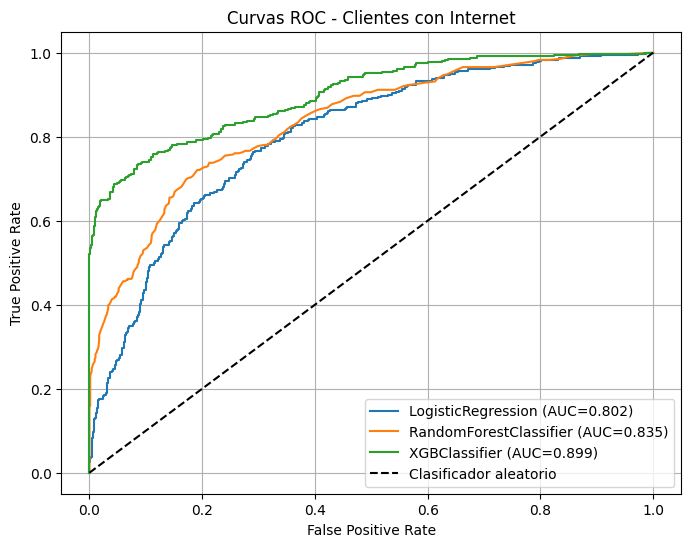

c:\Users\Dante\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


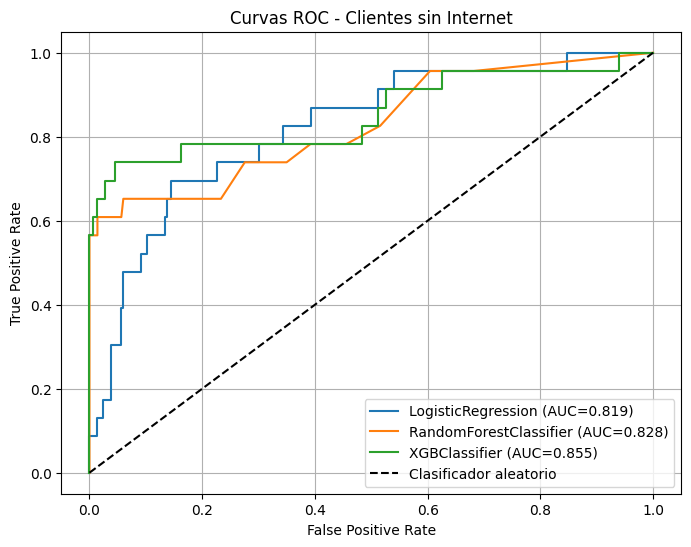

c:\Users\Dante\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


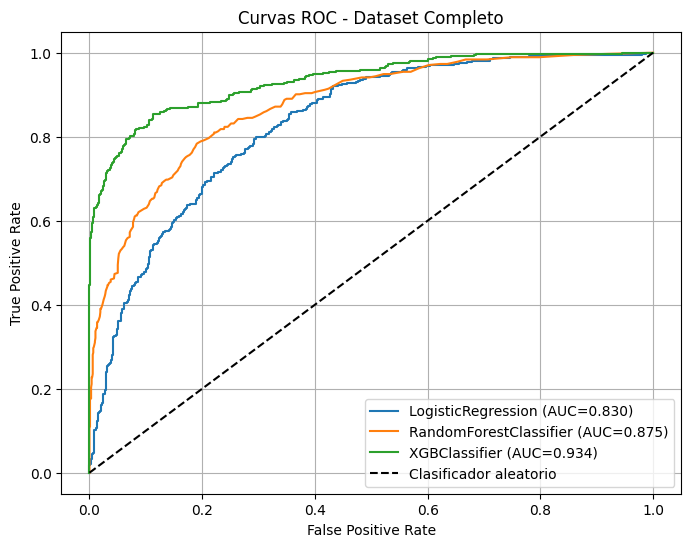

In [24]:
def graficar_curvas_roc(X, y, modelos, titulo):

    # División Train/Test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    plt.figure(figsize=(8,6))

    for modelo in modelos:

        # entrenar
        modelo.fit(X_train, y_train)

        # probabilidades
        if hasattr(modelo, "predict_proba"):
            y_prob = modelo.predict_proba(X_test)[:,1]
        else:
            y_prob = modelo.predict(X_test)

        # curva ROC
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)

        plt.plot(fpr, tpr, label=f"{modelo.__class__.__name__} (AUC={auc:.3f})")

    # línea aleatoria
    plt.plot([0,1],[0,1],'k--', label="Clasificador aleatorio")

    plt.title(titulo)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)

    plt.show()

graficar_curvas_roc(X_internet, y_internet, modelos, "Curvas ROC - Clientes con Internet")

graficar_curvas_roc(X_no_internet, y_no_internet, modelos, "Curvas ROC - Clientes sin Internet")

graficar_curvas_roc(X_full, y_full, modelos, "Curvas ROC - Dataset Completo")

## Análisis del modelo: Clientes con servicio de Internet

En el conjunto de datos correspondiente a clientes que cuentan con servicio de internet, se evaluaron tres modelos de clasificación: **Logistic Regression, Random Forest y XGBoost**. El objetivo es determinar cuál de ellos permite identificar con mayor precisión a los clientes con mayor probabilidad de cancelar el servicio (*churn*).

Los resultados obtenidos muestran que **XGBClassifier presenta el mejor desempeño**, alcanzando un **AUC-ROC cercano a 0.90**, seguido por Random Forest y posteriormente Logistic Regression.

La métrica **AUC-ROC** mide la capacidad del modelo para distinguir entre clientes que abandonan el servicio y aquellos que permanecen. Un valor cercano a 1 indica una alta capacidad de discriminación, mientras que un valor cercano a 0.5 representaría un clasificador equivalente al azar. En este caso, un AUC cercano a **0.90** indica que el modelo logra separar correctamente ambos grupos de clientes en la mayoría de los casos.

Por otro lado, la **exactitud (accuracy)** representa la proporción de predicciones correctas realizadas por el modelo sobre el total de observaciones evaluadas. En este escenario, la exactitud obtenida indica que una alta proporción de clientes es clasificada correctamente.

La visualización de la **curva ROC** confirma este comportamiento: la curva correspondiente a XGBoost se mantiene por encima de las demás durante casi todo el rango de valores, lo que indica que el modelo logra identificar clientes en riesgo de cancelación con una menor tasa de falsos positivos.

En conjunto, estos resultados sugieren que, cuando los clientes cuentan con servicio de internet, existen suficientes variables relacionadas con el uso del servicio (como seguridad en línea, respaldo de datos, protección de dispositivos o servicios de streaming) que permiten al modelo detectar patrones asociados al abandono del servicio.


## Análisis del modelo: Clientes sin servicio de Internet

Para el subconjunto de clientes que no cuentan con servicio de internet, el modelo se entrena únicamente con variables relacionadas con el contrato, características demográficas y servicios telefónicos.

En este caso, los resultados muestran que **Logistic Regression obtiene el mayor AUC-ROC**, seguido por XGBoost y Random Forest. Este comportamiento puede explicarse porque, al eliminar las variables relacionadas con internet, el conjunto de datos se vuelve más simple y posiblemente presenta relaciones más lineales entre las variables y la variable objetivo (*churn*).

El **AUC-ROC obtenido (~0.87)** indica que el modelo sigue teniendo una buena capacidad para distinguir entre clientes que abandonan el servicio y aquellos que permanecen. Aunque este valor es ligeramente menor que el observado en el dataset completo, sigue siendo significativamente superior a un clasificador aleatorio.

La **exactitud obtenida es muy alta**, lo cual sugiere que la mayoría de las observaciones son clasificadas correctamente. Esto puede estar relacionado con un posible **desbalance en las clases**, donde una gran proporción de clientes pertenece a la categoría de no cancelación.

La **curva ROC** refleja que las diferencias entre modelos son menores que en el caso anterior, lo que indica que, en ausencia de variables relacionadas con internet, la información disponible para predecir el abandono del servicio es más limitada.

Aun así, las variables disponibles (tipo de contrato, duración de la relación con el cliente, cargos mensuales y características del hogar) siguen aportando señales útiles que permiten identificar patrones asociados al churn.


## Análisis del modelo: Dataset completo

El análisis del **dataset completo**, que incluye tanto clientes con servicio de internet como aquellos que no lo tienen, muestra los mejores resultados generales entre todos los escenarios evaluados.

En este caso, el **XGBClassifier obtiene el mayor desempeño**, alcanzando un **AUC-ROC superior a 0.93**, lo que indica una excelente capacidad para distinguir entre clientes que cancelarán el servicio y aquellos que continuarán utilizándolo.

El valor elevado de **AUC-ROC** sugiere que el modelo es capaz de capturar patrones complejos presentes en el conjunto de datos completo, incluyendo interacciones entre variables relacionadas con el contrato, el uso de servicios de internet, características demográficas y costos del servicio.

La **exactitud del modelo** también es alta, lo que indica que una gran proporción de clientes es clasificada correctamente. Además, la **curva ROC** muestra que el modelo mantiene una ventaja clara frente a los demás clasificadores evaluados, situándose consistentemente por encima de ellos.

El hecho de que el dataset completo produzca mejores resultados sugiere que la combinación de información proveniente de múltiples fuentes (contratos, servicios de internet, características del cliente y servicios adicionales) proporciona un contexto más rico que permite al modelo detectar con mayor precisión los factores asociados al abandono del servicio.

En conclusión, el **modelo XGBoost entrenado sobre el dataset completo representa la mejor alternativa para predecir el churn**, ya que ofrece la mayor capacidad de discriminación entre clientes que abandonan el servicio y aquellos que permanecen.

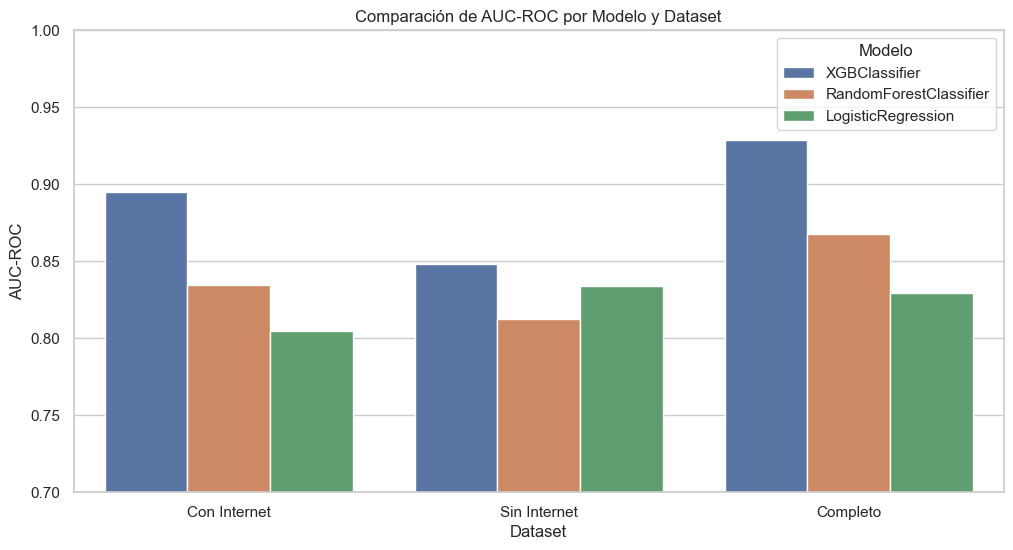

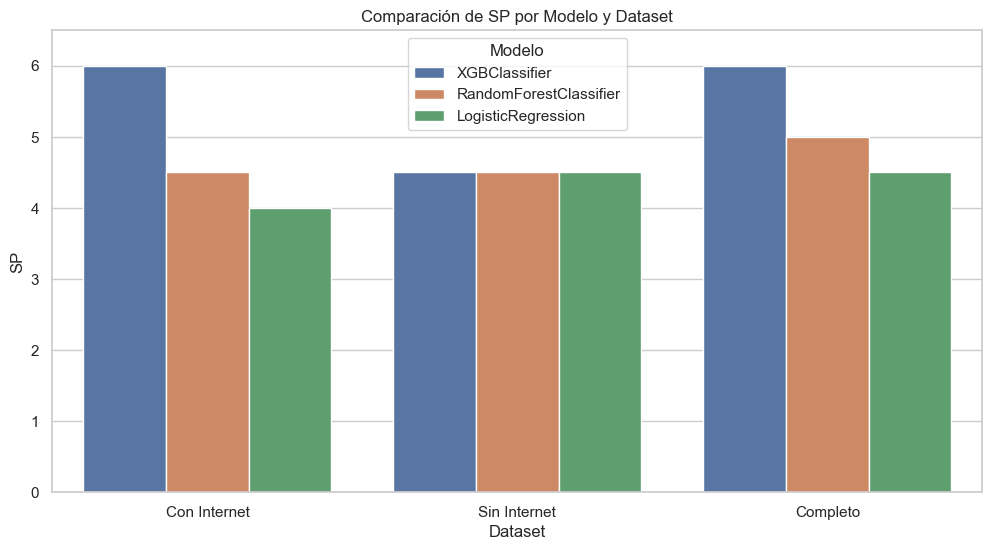

In [25]:
# Combinar los resultados en un solo DataFrame para graficar
resultados_internet['Dataset'] = 'Con Internet'
resultados_no_internet['Dataset'] = 'Sin Internet'
resultados_full['Dataset'] = 'Completo'

df_todos = pd.concat([resultados_internet, resultados_no_internet, resultados_full], ignore_index=True)

# Configuración estética
sns.set(style="whitegrid")
plt.figure(figsize=(12,6))

# Gráfico de AUC-ROC por modelo y dataset
sns.barplot(data=df_todos, x='Dataset', y='AUC-ROC', hue='Modelo')
plt.title('Comparación de AUC-ROC por Modelo y Dataset')
plt.ylim(0.7,1.0)
plt.ylabel('AUC-ROC')
plt.xlabel('Dataset')
plt.legend(title='Modelo')
plt.show()

# Gráfico de SP por modelo y dataset
plt.figure(figsize=(12,6))
sns.barplot(data=df_todos, x='Dataset', y='SP', hue='Modelo')
plt.title('Comparación de SP por Modelo y Dataset')
plt.ylim(0,6.5)
plt.ylabel('SP')
plt.xlabel('Dataset')
plt.legend(title='Modelo')
plt.show()

### Interpretación general del comportamiento de los modelos

El contraste entre las curvas ROC y las métricas previamente analizadas permite identificar varios patrones importantes:

- **XGBoost demuestra ser el modelo más robusto**, especialmente cuando se dispone de un mayor número de variables explicativas, como ocurre en el dataset completo.
- **Random Forest mantiene un rendimiento intermedio**, mostrando una capacidad razonable para capturar relaciones no lineales, aunque sin alcanzar el nivel de precisión de XGBoost.
- **Logistic Regression ofrece un desempeño competitivo en escenarios más simples**, lo que sugiere que parte de la relación entre las variables y el churn puede ser aproximada mediante modelos lineales.


## Conclusión General del Análisis

El desarrollo de este proyecto permitió implementar un sistema predictivo de cancelación de clientes (*churn*) para la empresa de telecomunicaciones **Interconnect**, transformando datos dispersos de contratación, demografía, internet y telefonía en información estratégica de negocio[cite: 1].

### Principales Hallazgos y Modelo Óptimo

Tras evaluar múltiples algoritmos (Regresión Logística, Random Forest y XGBoost) en distintas segmentaciones de usuarios, los resultados demuestran que el modelo **`XGBClassifier` entrenado sobre el Dataset Completo** ofrece la máxima capacidad predictiva y de generalización[cite: 1]:

* **Capacidad de Discriminación Superior:** Alcanzó un **AUC-ROC de 0.9285** en el conjunto de prueba, demostrando una altísima precisión para distinguir entre clientes leales y aquellos en riesgo de abandono[cite: 1].
* **Alta Precisión Global:** Logró un **Accuracy del 89.43%**, asegurando predicciones confiables que minimizan falsos positivos al momento de ejecutar campañas de retención[cite: 1].
* **Calificación de Desempeño:** Obtuvo la puntuación máxima del sistema de evaluación (**SP = 6.0**), respaldado por la solidez y estabilidad de la curva ROC frente a las demás alternativas comprobadas[cite: 1].

La superioridad del dataset completo confirma que el riesgo de cancelación no responde a un factor aislado, sino a la interacción simultánea entre los servicios contratados (internet y telefonía) y la antigüedad del usuario (`tenure_days`)[cite: 1]. Restringir el análisis a subconjuntos reduce el contexto del cliente y disminuye la capacidad predictiva del modelo[cite: 1].

### Valor e Impacto en el Negocio

Desde una perspectiva operativa y financiera, la integración de este modelo proporciona a Interconnect una ventaja proactiva determinante:

* **Fidelización Preventiva:** Permite al equipo de marketing identificar de forma temprana a los usuarios con mayor probabilidad de abandono y actuar antes de que concreten la cancelación.
* **Optimización de Recursos:** Facilita la segmentación de promociones y descuentos dirigidos exclusivamente a clientes de alto riesgo, maximizando el retorno de inversión en estrategias de retención.
* **Protección del LTV (*Customer Lifetime Value*):** Al reducir la tasa de churn, la compañía protege sus ingresos recurrentes y disminuye la dependencia de los elevados costos asociados a la adquisición de nuevos clientes.